# Datenanalyse mit SQL & Python - Tag 4: Explorative Datenanalyse & Reporting

**Donnerstag:** EDA, Data Cleaning und Reporting mit einem echten messy Job-Posting-Datensatz.  
**Business-Fokus:** Welche Faktoren hängen mit Data-Science-Gehältern zusammen?


## Ablauf

**Tag 4 - Explorative Datenanalyse & Reporting**

| Zeit | Thema | Fokus |
|---|---|---|
| 09:00-09:30 | Wiederholung | Datenaufbereitung & Visualisierung |
| 09:30-10:30 | Explorative Datenanalyse (EDA) | Statistische Kennzahlen, Verteilungen, Korrelationen |
| 10:30-11:30 | Datenbereinigung | Missing Values, Duplikate, Textformate |
| 11:30-12:10 | Mittagspause | - |
| 12:10-14:00 | Zeitreihenanalyse und Trendermittlung | Trends erkennen, SQL + Python |
| 14:00-14:20 | Pause | - |
| 14:20-15:40 | Praktische Uebung | Mini-Projekt & Praesentation |
| 15:40-16:00 | Ergebnisse & Diskussion | Praesentation, Reflexion, Q&A |


## Lernziele

Nach Tag 4 kannst du:

- Explorative Datenanalyse (EDA) mit statistischen Kennzahlen, Verteilungen und Korrelationen durchführen
- typische Datenqualitätsprobleme in einem realistischeren Rohdatensatz erkennen
- Text-, Gehalts- und Standortspalten mit Pandas bereinigen
- SQL und Python kombinieren, um komplexere Analysefragen zu beantworten
- aussagekräftige Diagramme und kurze Reports erstellen
- aus einer EDA eine datenbasierte Business-Empfehlung ableiten


## Themen des Tages

1. Job-Posting-Daten verstehen und erste EDA durchführen
1. Datenbereinigung: fehlende Werte, Typen, Duplikate, Textspalten
1. Gehaltsspannen, Standort und Firmenalter analysierbar machen
1. Zeitreihenanalyse: Trend, Saison und gleitender Durchschnitt
1. Kombination von SQL und Python für komplexere Analysen
1. Reporting mit SCR: Von Diagrammen zu Entscheidungen
1. Mini-Projekt: Faktoren für Data-Science-Gehälter untersuchen

## Einrichtung & Daten laden

Wir nutzen `Uncleaned_DS_jobs.csv` aus dem öffentlichen Repository `eyowhite/Messy-dataset`.

Quelle: https://github.com/eyowhite/Messy-dataset


In [10]:
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 100)

JOB_DATA_URL = 'https://raw.githubusercontent.com/eyowhite/Messy-dataset/main/Uncleaned_DS_jobs.csv'

jobs_raw = pd.read_csv(JOB_DATA_URL, engine='python', on_bad_lines='warn')
jobs_raw = jobs_raw.drop(columns='index')
print('Rohdaten:', jobs_raw.shape)
jobs_raw.head()


Rohdaten: (672, 14)


,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna"
1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1
2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1
3,Data Scientist,$137K-$171K (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech..."
4,Data Scientist,$137K-$171K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"


# 09:00–09:30 | Wiederholung & Einstieg

## 1. Einstieg: Warum ist dieser Datensatz besser für Tag 4?

Der Shop-Datensatz aus den vorherigen Tagen ist klein und relativ sauber. Für Tag 4 brauchen wir mehr Reibung:

- Textspalten mit Zusatzinformationen
- Gehaltsspannen als Strings
- uneinheitliche Firmenangaben
- negative oder fehlende Werte als Platzhalter
- mehrere mögliche Analysepfade

Genau deshalb eignet sich ein unbereinigter Job-Posting-Datensatz gut für EDA & Reporting.


# 09:30–10:30 | Explorative Datenanalyse (EDA)

## 2. EDA-Schnellcheck und analysefähige Spalten

EDA bedeutet: Wir verschaffen uns schnell ein belastbares Bild vom Datensatz, bevor wir Entscheidungen treffen.

Für diesen Datensatz brauchen wir zuerst einige analysefähige Spalten. Die Gehaltsspanne, der Standort und das Gründungsjahr liegen nicht direkt in idealer Form vor. Deshalb erstellen wir eine Arbeitskopie `jobs`, die wir anschließend für EDA und Cleaning weiterverwenden.

In [11]:
print('Form:', jobs_raw.shape)
print()
print('Spalten:')
print(jobs_raw.columns.tolist())
print()
print('Datentypen:')
print(jobs_raw.dtypes)
print()
print('Fehlende Werte:')
print(jobs_raw.isna().sum().sort_values(ascending=False).head(20))

Form: (672, 14)

Spalten:
['Job Title', 'Salary Estimate', 'Job Description', 'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded', 'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors']

Datentypen:
Job Title                str
Salary Estimate          str
Job Description          str
Rating               float64
Company Name             str
Location                 str
Headquarters             str
Size                     str
Founded                int64
Type of ownership        str
Industry                 str
Sector                   str
Revenue                  str
Competitors              str
dtype: object

Fehlende Werte:
Job Title            0
Salary Estimate      0
Job Description      0
Rating               0
Company Name         0
Location             0
Headquarters         0
Size                 0
Founded              0
Type of ownership    0
Industry             0
Sector               0
Revenue              0
Competitors          0
dtype: i

In [12]:
jobs_raw.describe(include='all').T.head(20)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Job Title,672,172,Data Scientist,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Salary Estimate,672,30,$75K-$131K (Glassdoor est.),32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job Description,672,489,Job Overview: The Data Scientist is a key memb...,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,672.0,NaN,NaN,NaN,3.518601,1.410329,-1.0,3.3,3.8,4.3,5.0
Company Name,672,432,Maxar Technologies\n3.5,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,672,207,"San Francisco, CA",69,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Headquarters,672,229,"New York, NY",33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Size,672,9,51 to 200 employees,135,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Founded,672.0,NaN,NaN,NaN,1635.529762,756.74664,-1.0,1917.75,1995.0,2009.0,2019.0
Type of ownership,672,13,Company - Private,397,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### EDA-Arbeitskopie vorbereiten

Wir erstellen die wichtigsten Analysefelder direkt vor der EDA. Das ist noch keine vollständige Datenbereinigung, sondern eine pragmatische Vorbereitung für erste Kennzahlen und Diagramme.

In [ ]:
jobs = jobs_raw.copy()

if 'index' in jobs.columns:
    jobs = jobs.drop(columns='index')

jobs.columns = (
    jobs.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('-', '_')
)

text_cols = jobs.select_dtypes(include=['object']).columns
for col in text_cols:
    jobs[col] = jobs[col].astype('string').str.strip()

jobs = jobs.replace(-1, np.nan).replace('-1', pd.NA)

salary_clean = (
    jobs['salary_estimate']
    .astype('string')
    .str.replace(r'\(.*\)', '', regex=True)
    .str.replace('K', '', regex=False)
    .str.replace('$', '', regex=False)
    .str.strip()
)

salary_parts = salary_clean.str.extract(r'(?P<min_salary>\d+)\s*-\s*(?P<max_salary>\d+)')
jobs['min_salary_k'] = pd.to_numeric(salary_parts['min_salary'], errors='coerce')
jobs['max_salary_k'] = pd.to_numeric(salary_parts['max_salary'], errors='coerce')
jobs['avg_salary_k'] = jobs[['min_salary_k', 'max_salary_k']].mean(axis=1)

if 'company_name' in jobs.columns:
    jobs['company_clean'] = jobs['company_name'].astype('string').str.replace(r'\n.*', '', regex=True).str.strip()

if 'founded' in jobs.columns:
    jobs['company_age'] = 2026 - pd.to_numeric(jobs['founded'], errors='coerce')
    jobs.loc[jobs['company_age'] < 0, 'company_age'] = np.nan

if 'location' in jobs.columns:
    jobs['state'] = jobs['location'].astype('string').str.extract(r',\s*([A-Z]{2})$')

jobs[['salary_estimate', 'min_salary_k', 'max_salary_k', 'avg_salary_k', 'state', 'company_age']].head(10)

# 09:30–10:30 | EDA: Verteilungen, Gruppen & Korrelationen

## 4. Univariate EDA: Gehaltsverteilung und Ratings

Jetzt analysieren wir einzelne Variablen: Gehalt, Rating und Firmenalter.


In [20]:
jobs[['min_salary_k', 'max_salary_k', 'avg_salary_k', 'rating', 'company_age']].describe().T


,count,mean,std,min,25%,50%,75%,max
min_salary_k,672.0,99.196429,33.009958,31.0,79.0,91.0,122.0,212.0
max_salary_k,672.0,148.130952,48.03511,56.0,119.0,133.0,165.0,331.0
avg_salary_k,672.0,123.66369,39.580268,43.5,103.0,114.0,136.5,271.5
rating,622.0,3.881833,0.610805,2.0,3.5,3.8,4.4,5.0
company_age,554.0,41.895307,40.653609,7.0,16.0,27.0,52.0,245.0


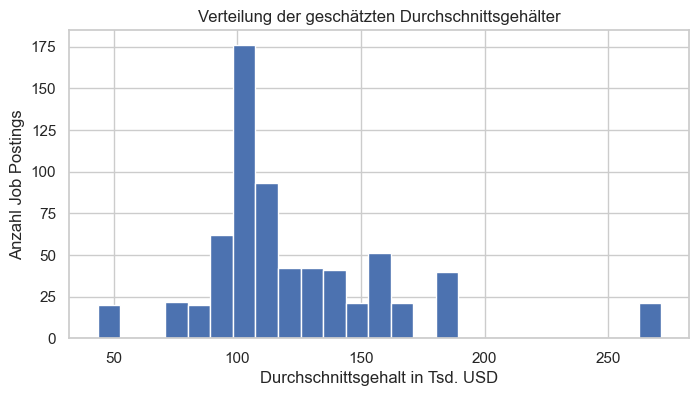

In [23]:
plt.figure(figsize=(8, 4))
plt.hist(jobs['avg_salary_k'].dropna(), bins=25)
plt.title('Verteilung der geschätzten Durchschnittsgehälter')
plt.xlabel('Durchschnittsgehalt in Tsd. USD')
plt.ylabel('Anzahl Job Postings')
plt.show()


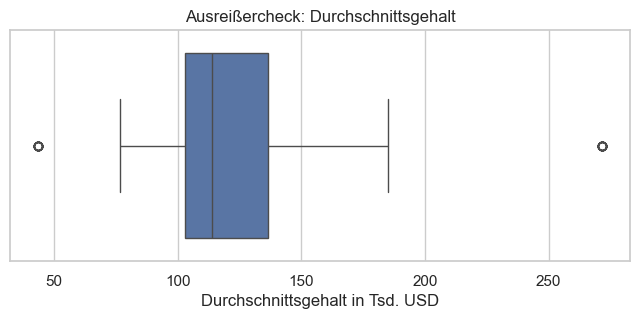

In [24]:
plt.figure(figsize=(8, 3))
sns.boxplot(data=jobs, x='avg_salary_k')
plt.title('Ausreißercheck: Durchschnittsgehalt')
plt.xlabel('Durchschnittsgehalt in Tsd. USD')
plt.show()


## 5. Bivariate EDA: Gruppen vergleichen

Wir vergleichen Gehalt nach Standort, Branche oder Sektor. Je nach Datenqualität können einzelne Spalten leer sein.


In [25]:
state_salary = (
    jobs
    .dropna(subset=['state', 'avg_salary_k'])
    .groupby('state')['avg_salary_k']
    .agg(['count', 'mean', 'median'])
    .query('count >= 5')
    .sort_values('mean', ascending=False)
)
state_salary.head(10)


,count,mean,median
state,,,
NC,9,150.111111,136.5
WI,6,144.416667,145.25
DC,26,139.5,115.5
NY,52,136.432692,120.5
TX,17,136.058824,114.0
WA,16,134.78125,117.25
VA,89,126.769663,115.5
PA,12,125.833333,126.75
OK,6,122.916667,103.25


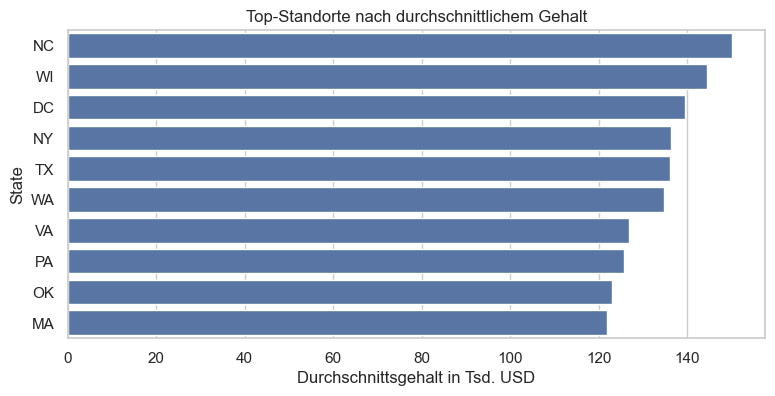

In [26]:
plt.figure(figsize=(9, 4))
sns.barplot(data=state_salary.head(10).reset_index(), x='mean', y='state')
plt.title('Top-Standorte nach durchschnittlichem Gehalt')
plt.xlabel('Durchschnittsgehalt in Tsd. USD')
plt.ylabel('State')
plt.show()


In [27]:
if 'sector' in jobs.columns:
    sector_salary = (
        jobs
        .dropna(subset=['sector', 'avg_salary_k'])
        .groupby('sector')['avg_salary_k']
        .agg(['count', 'mean', 'median'])
        .query('count >= 5')
        .sort_values('mean', ascending=False)
    )
    display(sector_salary.head(10))


,count,mean,median
sector,,,
Media,5,155.3,115.5
Retail,7,150.142857,154.0
Government,17,134.470588,136.5
Aerospace & Defense,46,132.695652,123.5
Business Services,120,130.079167,114.0
Manufacturing,23,123.23913,115.5
Biotech & Pharmaceuticals,66,122.871212,106.5
Health Care,21,119.761905,114.0
Information Technology,188,118.909574,113.0


## 6. Korrelationen

Wir prüfen, ob numerische Variablen wie Rating, Firmenalter und Gehalt zusammenhängen.


In [28]:
numeric_cols = [col for col in ['avg_salary_k', 'rating', 'company_age'] if col in jobs.columns]
corr = jobs[numeric_cols].corr()
corr


,avg_salary_k,rating,company_age
avg_salary_k,1.000000,0.001481,0.002549
rating,0.001481,1.000000,-0.190126
company_age,0.002549,-0.190126,1.000000


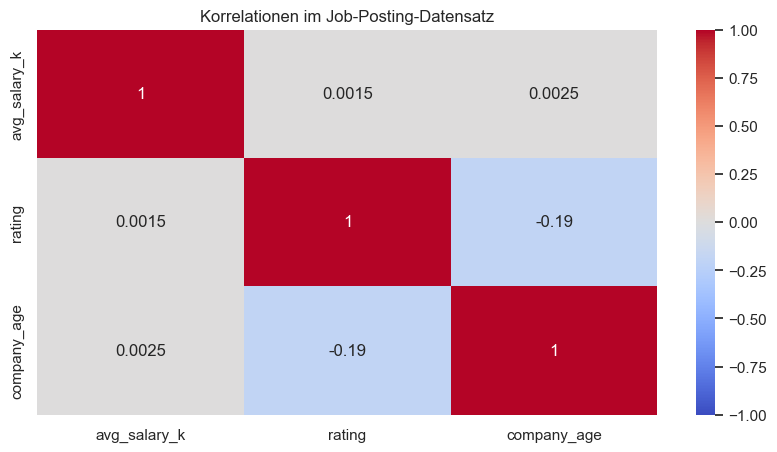

In [29]:
sns.heatmap(corr, annot=True, vmin=-1, vmax=1, cmap='coolwarm')
plt.title('Korrelationen im Job-Posting-Datensatz')
plt.show()


# 10:30–11:30 | Datenbereinigung

## 3. Data Cleaning: Analysebasis prüfen und verbessern

Nach der ersten EDA vertiefen wir die Bereinigung. Ziel ist keine perfekte Datei, sondern eine nachvollziehbare Analysebasis für Gehälter, Standorte, Branchen und Ratings.

In [8]:
print('Bereinigte Arbeitskopie:', jobs.shape)
print()
print('Fehlende Werte in zentralen Analysefeldern:')
print(jobs[['avg_salary_k', 'rating', 'sector', 'state', 'company_age']].isna().sum())

jobs.head()

/var/folders/g3/xwx5rk_j3vgg81zv4cx9701m0000gn/T/ipykernel_49526/693467424.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = jobs.select_dtypes(include=['object']).columns


,job_title,salary_estimate,job_description,rating,company_name,location,headquarters,size,founded,type_of_ownership,industry,sector,revenue,competitors
0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993.0,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna"
1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968.0,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),<NA>
2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981.0,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),<NA>
3,Data Scientist,$137K-$171K (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000.0,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech..."
4,Data Scientist,$137K-$171K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998.0,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"


### 3.1 Gehaltsspanne prüfen

Die Spalte `salary_estimate` war Text. In der EDA-Vorbereitung wurden daraus minimale, maximale und durchschnittliche Gehaltswerte extrahiert. Hier prüfen wir kurz, ob die Umwandlung plausibel aussieht.

In [18]:
jobs[['salary_estimate', 'min_salary_k', 'max_salary_k', 'avg_salary_k']].head(10)

,salary_estimate,min_salary_k,max_salary_k,avg_salary_k
0,$137K-$171K (Glassdoor est.),137,171,154.0
1,$137K-$171K (Glassdoor est.),137,171,154.0
2,$137K-$171K (Glassdoor est.),137,171,154.0
3,$137K-$171K (Glassdoor est.),137,171,154.0
4,$137K-$171K (Glassdoor est.),137,171,154.0
5,$137K-$171K (Glassdoor est.),137,171,154.0
6,$137K-$171K (Glassdoor est.),137,171,154.0
7,$137K-$171K (Glassdoor est.),137,171,154.0
8,$137K-$171K (Glassdoor est.),137,171,154.0
9,$137K-$171K (Glassdoor est.),137,171,154.0


### 3.2 Firmenname, Standort und Alter der Firma prüfen

Auch Firmenname, Standort und Gründungsjahr wurden in analysefähige Felder überführt. Jetzt kontrollieren wir Beispiele aus diesen Spalten.

In [19]:
jobs[['company_clean', 'location', 'state', 'company_age']].head(10)

,company_clean,location,state,company_age
0,Healthfirst,"New York, NY",NY,33.0
1,ManTech,"Chantilly, VA",VA,58.0
2,Analysis Group,"Boston, MA",MA,45.0
3,INFICON,"Newton, MA",MA,26.0
4,Affinity Solutions,"New York, NY",NY,28.0
5,HG Insights,"Santa Barbara, CA",CA,16.0
6,Novartis,"Cambridge, MA",MA,30.0
7,iRobot,"Bedford, MA",MA,36.0
8,Intuit - Data,"San Diego, CA",CA,43.0
9,XSELL Technologies,"Chicago, IL",IL,12.0


### 3.3 Fehlende Werte mit Gruppenlogik auffüllen

Nicht jeder fehlende Wert sollte einfach gelöscht werden. Wenn eine numerische Spalte viele fehlende Werte hat, kann eine gruppenbasierte Imputation sinnvoll sein: Wir ersetzen fehlende Werte durch einen typischen Wert innerhalb einer passenden Gruppe.

Beispiel im Job-Datensatz: Fehlende `rating`-Werte werden mit dem Median-Rating des jeweiligen `sector` gefüllt. Falls ein Sector keinen Median hat, nutzen wir als Fallback den globalen Median.

Diese Logik ist später im Übungsdatensatz besonders wichtig: Dort kann `salary` nach `department` gefüllt werden.


In [ ]:
rating_missing_before = jobs['rating'].isna().sum()

sector_rating_median = jobs.groupby('sector')['rating'].transform('median')
global_rating_median = jobs['rating'].median()

jobs['rating_filled'] = jobs['rating'].fillna(sector_rating_median)
jobs['rating_filled'] = jobs['rating_filled'].fillna(global_rating_median)
jobs['rating_was_imputed'] = jobs['rating'].isna()

rating_missing_after = jobs['rating_filled'].isna().sum()

print('Fehlende Ratings vorher:', rating_missing_before)
print('Fehlende Ratings nachher:', rating_missing_after)

jobs.loc[
    jobs['rating_was_imputed'],
    ['company_clean', 'sector', 'rating', 'rating_filled', 'rating_was_imputed']
].head(10)


# 11:30–12:10 | 🍽️ Mittagspause

# 12:10–14:00 | Zeitreihenanalyse und Trendermittlung

Der Job-Posting-Datensatz enthält keine saubere Datumsspalte. Deshalb nutzen wir hier bewusst ein kleines synthetisches Beispiel aus Tag 3 und erweitern es um typische Zeitreihenmethoden: Datumsindex, `resample()` und `rolling()`.

## 7. Zeitreihenanalyse: Trend, Saison und gleitender Durchschnitt

Zeitreihen helfen, Entwicklungen über die Zeit zu erkennen. Typische Fragen sind:

- Gibt es einen Trend nach oben oder unten?
- Gibt es saisonale Muster?
- Wie glätten wir kurzfristige Schwankungen?

In [ ]:
np.random.seed(42)

dates = pd.date_range(start='2023-01-01', periods=24, freq='ME')

trend_a = np.linspace(10, 40, 24)
season_a = 4 * np.sin(np.linspace(0, 4 * np.pi, 24))
noise_a = np.random.normal(0, 1.5, 24)
values_a = trend_a + season_a + noise_a

trend_b = np.linspace(5, 55, 24)
season_b = 6 * np.sin(np.linspace(0, 4 * np.pi, 24))
noise_b = np.random.normal(0, 2.5, 24)
values_b = trend_b + season_b + noise_b

time_series = pd.concat([
    pd.DataFrame({'date': dates, 'product': 'Product A', 'value': values_a}),
    pd.DataFrame({'date': dates, 'product': 'Product B', 'value': values_b})
], ignore_index=True)

time_series.head()

In [ ]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=time_series, x='date', y='value', hue='product', marker='o')
plt.title('Monatliche Zeitreihe nach Produkt')
plt.xlabel('Datum')
plt.ylabel('Wert')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Trend, Saison und Rauschen sichtbar machen

Das Beispiel ist bewusst konstruiert: Wir kennen den zugrunde liegenden Trend, die saisonale Schwankung und das zufällige Rauschen. Dadurch können wir lernen, was ein Zeitreihenplot zeigt und was man nur vorsichtig interpretieren sollte.

In [ ]:
product_a_components = pd.DataFrame({
    'date': dates,
    'value': values_a,
    'trend': trend_a,
    'season': season_a,
    'noise': noise_a
})

plt.figure(figsize=(10, 4))
plt.plot(product_a_components['date'], product_a_components['value'], label='Gesamtwert', marker='o')
plt.plot(product_a_components['date'], product_a_components['trend'], linestyle='--', linewidth=3, label='Trend')
plt.title('Product A: Gesamtverlauf mit Trend')
plt.xlabel('Datum')
plt.ylabel('Wert')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(product_a_components['date'], product_a_components['trend'], label='Trend')
plt.plot(product_a_components['date'], product_a_components['season'], label='Saison')
plt.plot(product_a_components['date'], product_a_components['noise'], label='Rauschen')
plt.title('Product A: Einzelne Komponenten der Zeitreihe')
plt.xlabel('Datum')
plt.ylabel('Wert')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Interpretation:

- Der **Trend** zeigt die langfristige Richtung.
- Die **Saison** zeigt wiederkehrende Schwankungen.
- Das **Rauschen** ist der zufällige Teil, den wir nicht systematisch erklären sollten.

### Datumsindex und Resampling

Mit einem Datumsindex können wir Zeiträume zusammenfassen, zum Beispiel monatliche Werte zu Quartalen.

In [ ]:
ts_indexed = time_series.set_index('date')

quarterly = (
    ts_indexed
    .groupby('product')
    .resample('QE')['value']
    .mean()
    .rename('quarterly_avg')
    .reset_index()
)

quarterly.head(8)

In [ ]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=quarterly, x='date', y='quarterly_avg', hue='product', marker='o')
plt.title('Quartalsdurchschnitt pro Produkt')
plt.xlabel('Quartal')
plt.ylabel('Durchschnittlicher Wert')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Rolling Average: kurzfristige Schwankungen glätten

Ein gleitender Durchschnitt zeigt den Trend klarer, weil einzelne Ausreißer weniger stark wirken.

In [ ]:
time_series = time_series.sort_values(['product', 'date']).copy()
time_series['rolling_3_month_avg'] = (
    time_series
    .groupby('product')['value']
    .transform(lambda s: s.rolling(window=3, min_periods=1).mean())
)

time_series.head(8)

In [ ]:
product_a = time_series[time_series['product'] == 'Product A']

plt.figure(figsize=(10, 4))
plt.plot(product_a['date'], product_a['value'], marker='o', alpha=0.5, label='Original')
plt.plot(product_a['date'], product_a['rolling_3_month_avg'], linewidth=3, label='3-Monats-Durchschnitt')
plt.title('Product A: Originalwert vs. gleitender Durchschnitt')
plt.xlabel('Datum')
plt.ylabel('Wert')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Mini-Übung: Zeitreihe interpretieren

1. Welches Produkt wächst stärker?
2. In welchen Monaten wirken saisonale Schwankungen besonders sichtbar?
3. Was zeigt der gleitende Durchschnitt besser als die Originalwerte?

## 8. SQL + Python für komplexere Analysen

Wir speichern den bereinigten DataFrame in SQLite und führen eine aggregierte Analyse aus.

In [30]:
conn = sqlite3.connect(':memory:')
jobs.to_sql('jobs', conn, index=False, if_exists='replace')

query = '''
SELECT
    state,
    COUNT(*) AS postings,
    AVG(avg_salary_k) AS avg_salary_k,
    AVG(rating) AS avg_rating
FROM jobs
WHERE state IS NOT NULL
  AND avg_salary_k IS NOT NULL
GROUP BY state
HAVING COUNT(*) >= 5
ORDER BY avg_salary_k DESC;
'''

sql_state_report = pd.read_sql_query(query, conn)
sql_state_report.head(10)


,state,postings,avg_salary_k,avg_rating
0,NC,9,150.111111,4.055556
1,WI,6,144.416667,4.166667
2,DC,26,139.500000,3.942308
3,NY,52,136.432692,3.875000
4,TX,17,136.058824,3.964706
5,WA,16,134.781250,3.440000
6,VA,89,126.769663,3.956410
7,PA,12,125.833333,3.381818
8,OK,6,122.916667,3.566667
9,MA,62,121.967742,3.977966


# 14:00–14:20 | ☕ Pause

# 14:20–15:40 | Reporting & Mini-Projekt & Praxis mit Day_4_Exercise_Teil B

## 9. Reporting mit SCR: Von Diagrammen zu Entscheidungen

Eine gute EDA endet nicht nur mit Beobachtungen, sondern mit einer entscheidungsorientierten Aussage.

Das SCR-Framework hilft dabei:

- **So what:** Warum ist dieser Befund wichtig?
- **Context:** Welche Daten oder Einschränkungen erklären den Befund?
- **Recommendation:** Was sollte als nächstes getan werden?

Formuliere Insights nicht nur als Statistik, sondern als kurze Business-Aussage.

In [31]:
scr_insights = [
    {
        'So what': 'Gehälter unterscheiden sich deutlich nach Standort.',
        'Context': 'Die Analyse nutzt Job-Posting-Daten; einzelne Standorte haben unterschiedlich viele Einträge.',
        'Recommendation': 'Standorte mit hohen Durchschnittsgehältern priorisieren, aber nur bei ausreichender Fallzahl vergleichen.'
    },
    {
        'So what': 'Datenqualität beeinflusst, welche Aussagen belastbar sind.',
        'Context': 'Rating- und Gehaltsfelder enthalten fehlende oder aus Text extrahierte Werte.',
        'Recommendation': 'Fehlende Werte transparent markieren und kritische Kennzahlen vor Entscheidungen validieren.'
    },
    {
        'So what': 'Ein einzelner Faktor reicht selten für eine gute Empfehlung.',
        'Context': 'Standort, Sektor, Rating und Seniorität können gemeinsam mit Gehalt zusammenhängen.',
        'Recommendation': 'Für die nächste Analyse mehrere Faktoren kombiniert betrachten.'
    }
]

for nr, insight in enumerate(scr_insights, start=1):
    print(f"Insight {nr}")
    print('So what:', insight['So what'])
    print('Context:', insight['Context'])
    print('Recommendation:', insight['Recommendation'])
    print()

- Insight 1: Gehälter unterscheiden sich deutlich nach Standort.
- Insight 2: Nicht alle Felder sind sauber genug für jede Analysefrage.
- Insight 3: Für eine belastbare Empfehlung sollten Standort, Sektor und Job-Level gemeinsam betrachtet werden.


## Mini-Projekt: Welche Faktoren hängen mit Data-Science-Gehältern zusammen?

**Aufgabe:** Erstelle einen kurzen Report zur Frage:

> Welche Faktoren hängen im Job-Posting-Datensatz mit höheren Data-Science-Gehältern zusammen?

Mögliche Faktoren:

- Standort / State
- Sector oder Industry
- Rating
- Firmenalter
- Jobtitel oder Seniorität

**Ergebnis:** 2-3 Diagramme, 3 Insights im SCR-Format, 1 Empfehlung und 1 Hinweis zur Datenqualität.

Nutze pro Insight dieses Gerüst:

- **So what:** Warum ist der Befund relevant?
- **Context:** Welche Daten, Muster oder Einschränkungen stützen den Befund?
- **Recommendation:** Welche Entscheidung oder nächste Analyse folgt daraus?

# 15:40–16:00 | Zusammenfassung & Ausblick

## Zusammenfassung

Heute hast du EDA und Reporting an einem realistischeren Rohdatensatz geübt:

1. Rohdaten prüfen
1. zentrale Text- und Zahlenspalten bereinigen
1. Gehalt aus Text extrahieren
1. Verteilungen und Gruppen vergleichen
1. SQL und Python kombinieren
1. Erkenntnisse in eine Business-Story übersetzen


## Ausblick auf morgen

Morgen geht es von EDA und Reporting zu Data Storytelling und Abschlussprojekt:

- aus Analyseergebnissen eine klare Storyline entwickeln
- passende Diagramme für eine Botschaft auswählen
- Empfehlungen und Grenzen der Analyse sauber formulieren
- ein Mini-Projekt als kurze datenbasierte Präsentation vorbereiten
